In [4]:
#importar librerias 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# cargar archivos
traffic = pd.read_csv(r'C:\Users\U1080701\OneDrive - Sanofi\Documentos\Python projects\tomtom_traffic.csv')
eco = pd.read_csv(r'C:\Users\U1080701\OneDrive - Sanofi\Documentos\Python projects\oecd_city_economy.csv')

In [10]:

# mostrar las primeras 5 filas de traffic
traffic.head(5)


,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [11]:
# mostrar las primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


In [12]:
# Examinar la estructura de traffic
traffic.info()


<class 'pandas.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  str    
 1   City                            1004464 non-null  str    
 2   UpdateTimeUTC                   1004464 non-null  str    
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  str    
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtypes: float64(

In [13]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Year             30 non-null     int64
 1   City             30 non-null     str  
 2   Country          30 non-null     str  
 3   City GDP/capita  30 non-null     str  
 4   Unemployment %   30 non-null     str  
 5   PM2.5 (μg/m³)    30 non-null     str  
 6   Population (M)   30 non-null     str  
dtypes: int64(1), str(6)
memory usage: 1.8 KB


In [14]:
# Estandarizar los nombres de las columnas de traffic
#tu código aquí
traffic = traffic.rename(columns = {'City':'city','Country' : 'country', 'UpdateTimeUTC' : 'update_time_utc', 'JamsDelay' : 'jams_delay', 'TrafficIndexLive' : 'traffic_index_live', 'JamsLengthInKms' : 'jams_length_kms','JamsCount' : 'jams_count', 'TrafficIndexWeekAgo': 'traffic_index_week_ago', 'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago', 'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins', 'TravelTimeHistoricPer10KmsMins':'travel_time_hist_per_10kms_mins', 'MinsDelay' : 'mins_delay' })

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='str')

In [15]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí


eco = eco.rename(columns = {'Country': 'country', 'Year':'year','City':'city','City GDP/capita':'city_gdp_capita', 'Unemployment %':'unemployment_pct', 'PM2.5 (μg/m³)':'pm25_concentracion','Population (M)':'population_m'})
# verificar cambios
eco = eco.rename(columns={
    'unemployment_%': 'unemployment_pct',
    'population_M': 'population_m'
})


eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25_concentracion', 'population_m'],
      dtype='str')

In [16]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')

# verificar el cambio
traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  str           
 1   city                             1004464 non-null  str           
 2   update_time_utc                  1004464 non-null  datetime64[us]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[us]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_mins  1004464 

In [38]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.', regex=False)

cols_num = ['city_gdp_capita', 'unemployment_pct', 'population_m']
for col in cols_num:eco[col] = pd.to_numeric(eco[col], errors='coerce')
# Calcula la población total en unidades absolutas (Multiplica * 1000000)

eco['population'] = eco['population_m']*1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                30 non-null     int64  
 1   city                30 non-null     str    
 2   country             30 non-null     str    
 3   city_gdp_capita     30 non-null     int64  
 4   unemployment_pct    30 non-null     float64
 5   pm25_concentracion  30 non-null     str    
 6   population_m        30 non-null     float64
 7   population          30 non-null     float64
dtypes: float64(3), int64(2), str(3)
memory usage: 2.0 KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25_concentracion,population_m,population
0,2023,buenos-aires,Argentina,157820,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,144750,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,131420,9.8,"19,10",13.6,13600000.0


In [18]:
# Extraer el año de las fechas en update_time_utc

traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [19]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25_concentracion,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


In [20]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 =  traffic_2024.groupby(['city','year','country'])[['jams_delay','traffic_index_live', 'jams_length_kms', 'jams_count', 'mins_delay', 'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins']].mean().add_suffix('_mean').reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,year,country,jams_delay_mean,traffic_index_live_mean,jams_length_kms_mean,jams_count_mean,mins_delay_mean,travel_time_live_per_10kms_mins_mean,travel_time_hist_per_10kms_mins_mean
0,a-coruna,2024,ESP,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,2024,DEU,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,2024,DNK,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,2024,ARE,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,2024,TUR,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [22]:
# tu código aquí 
traffic_city_year_2024.sort_values(["travel_time_live_per_10kms_mins_mean"], ascending=False)

,city,year,country,jams_delay_mean,traffic_index_live_mean,jams_length_kms_mean,jams_count_mean,mins_delay_mean,travel_time_live_per_10kms_mins_mean,travel_time_hist_per_10kms_mins_mean
211,manila,2024,PHL,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
28,bangalore,2024,IND,546.968558,27.999134,65.354049,133.392378,1.678881,26.436224,24.757343
233,mumbai,2024,IND,706.003686,25.816565,70.921813,158.202949,1.443244,25.792121,24.348877
190,lima,2024,PER,1052.292789,31.031277,110.314770,213.453519,1.506305,25.674261,24.167956
46,bogota,2024,COL,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557
...,...,...,...,...,...,...,...,...,...,...
93,columbia,2024,USA,39.336796,12.009603,9.305238,11.014841,0.372796,9.383871,9.011075
103,den-bosch,2024,NLD,16.811029,17.399738,4.074150,3.610724,0.505566,9.335377,8.829811
379,winston-salem,2024,USA,25.945939,7.458500,5.160453,6.808700,0.091265,8.578693,8.487429
194,little-rock,2024,USA,19.537014,7.083481,4.791254,6.284894,0.072926,8.565401,8.492475


In [23]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25_concentracion','population']

# Usar .copy() para crear los dos nuevos datasets reducidos



# traffic_2024_small = traffic_city_year_2024[ ... ].copy()
traffic_2024_small = traffic_2024[left_cols].copy()
eco_2024_small = eco[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on =['city','year'],how = 'inner')

# Mostrar las primeras 5 filas
merged.head(5)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25_concentracion,population
0,buenos-aires,ARG,2024,138.3,11.0,44.6,43.0,-0.248936,16.569802,16.818738,18117.0,7.2,"14,50",15400000.0
1,buenos-aires,ARG,2024,66.8,9.0,26.6,27.0,-0.799344,16.142125,16.941469,18117.0,7.2,"14,50",15400000.0
2,buenos-aires,ARG,2024,33.5,5.0,8.6,14.0,-1.688390,15.614398,17.302789,18117.0,7.2,"14,50",15400000.0
3,buenos-aires,ARG,2024,25.7,3.0,2.6,9.0,-1.677855,15.369625,17.047480,18117.0,7.2,"14,50",15400000.0
4,buenos-aires,ARG,2024,34.6,2.0,3.8,12.0,-1.412564,15.215201,16.627765,18117.0,7.2,"14,50",15400000.0


In [24]:
merged.groupby(['city'])[['travel_time_live_per_10kms_mins','city_gdp_capita']].mean().sort_values(by="travel_time_live_per_10kms_mins",ascending=False)

,travel_time_live_per_10kms_mins,city_gdp_capita
city,,
lima,25.674261,13472.0
bogota,24.992185,11442.0
mexico-city,21.809092,21111.0
sao-paulo,20.801836,14703.0
recife,20.101569,9189.0
fortaleza,19.267171,8512.0
montevideo,18.892342,26176.0
belo-horizonte,18.304538,11124.0
buenos-aires,17.907916,18117.0


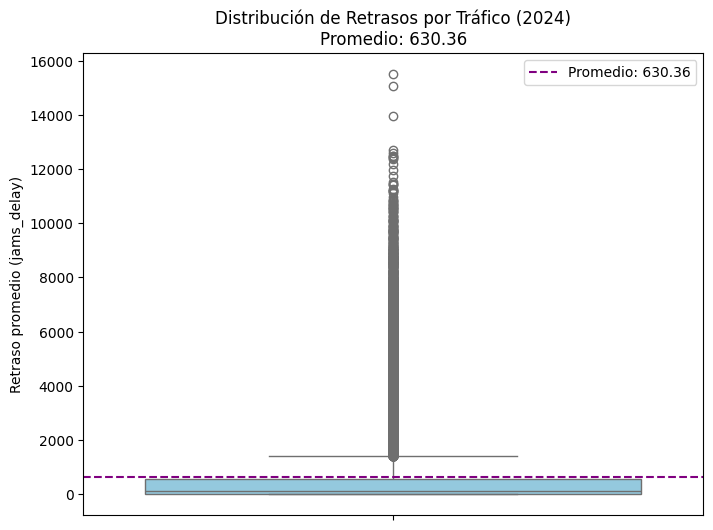

In [25]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico

# obtener promedio para mostrarlo en título


col_name = 'jams_delay' 

mean_value = merged[col_name].mean()

plt.figure(figsize=(8, 6))
sns.boxplot(y=merged[col_name], color='skyblue')

# 2. Añadir una línea horizontal para el promedio (opcional pero muy útil)
plt.axhline(mean_value, color='purple', linestyle='--', label=f'Promedio: {mean_value:.2f}')

plt.title(f'Distribución de Retrasos por Tráfico (2024)\nPromedio: {mean_value:.2f}')
plt.ylabel('Retraso promedio (jams_delay)')
plt.legend()
plt.show()

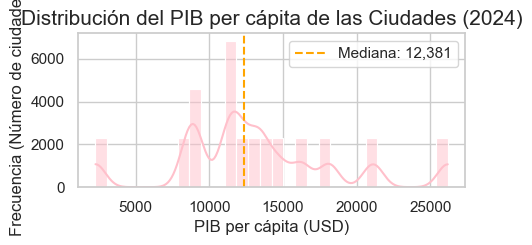

In [26]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 2))

sns.histplot(merged['city_gdp_capita'], kde=True, color='pink', bins=30)


mediana_gdp = merged['city_gdp_capita'].median()
plt.axvline(mediana_gdp, color='orange', linestyle='--', label=f'Mediana: {mediana_gdp:,.0f}')


plt.title('Distribución del PIB per cápita de las Ciudades (2024)', fontsize=15)
plt.xlabel('PIB per cápita (USD)', fontsize=12)
plt.ylabel('Frecuencia (Número de ciudades)', fontsize=12)
plt.legend()

plt.show()


In [27]:

# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay_mean','traffic_index_live_mean',
             'jams_length_kms_mean','jams_count_mean','mins_delay_mean',
             'travel_time_live_per_10kms_mins_mean','travel_time_hist_per_10kms_mins_mean']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25_concentracion','population']

# Usar .copy() para crear los dos nuevos datasets reducidos



# traffic_2024_small = traffic_city_year_2024[ ... ].copy()
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on =['city','year'],how = 'inner')

# Mostrar las primeras 5 filas
merged.head(5)

,city,country,year,jams_delay_mean,traffic_index_live_mean,jams_length_kms_mean,jams_count_mean,mins_delay_mean,travel_time_live_per_10kms_mins_mean,travel_time_hist_per_10kms_mins_mean,city_gdp_capita,unemployment_pct,pm25_concentracion,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


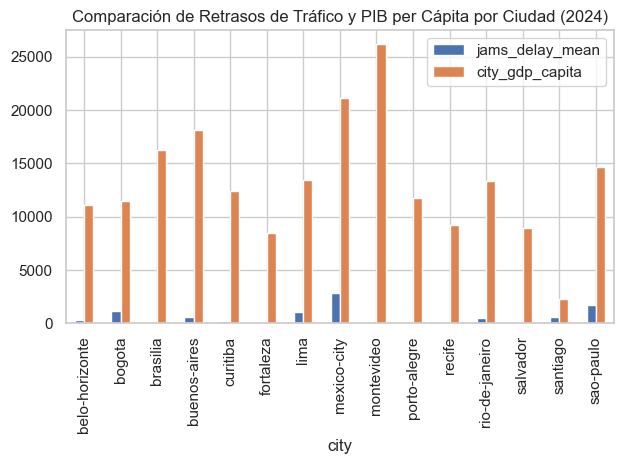

In [28]:
# Realiza el gráfico con tu código
merged.plot(kind='bar', x='city', y=['jams_delay_mean', 'city_gdp_capita'])

plt.xticks(rotation=90)

plt.title('Comparación de Retrasos de Tráfico y PIB per Cápita por Ciudad (2024)')

plt.tight_layout()  
plt.show()


In [29]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

# 🧾 Resumen ejecutivo 


1. **Contexto**: La premisa de este análisis es que el tiempo es un activo económico. Una ciudad con alta congestión sufre una "falta de productividad": los ciudadanos pasan horas no remuneradas en el tráfico en lugar de producir o consumir. Esto al final reduce calidad de vida y afecta la productividad.

Para este análisis se tomaron las siguientes variables Clave: jam_delays vs. city_gdp_capita.

Esta relación nos permite identificar dónde el tráfico actúa como un techo para el crecimiento económico.



2. **Cobertura de Datos y Metodología**

- Cobertura: Datos correspondientes al año 2024, abarcando ciudades clave en países como Argentina, Uruguay, Brasil, México, Colombia, Chile y Perú.

- Limpieza: Se estandarizaron nombres de columnas, se cambiaron los tipos de datos a numericos, se normalizaron las fechas por formato fecha, se normalizaron las cifras de población y PIB, y se agregó columna de 'year'.

- Integración: Se realizó una agregación por city y year mediante un INNER JOIN, asegurando que solo analizamos ciudades donde existía información tanto de movilidad (TomTom Traffic Index) como económica (OECD Cities).

- Validación: Se aplicaron filtros de outliers para evitar que picos de tráfico momentáneos distorsionaran el promedio anual de las ciudades.


3. **Hallazgos del Negocio**


¿Qué ciudades presentan alta congestión y baja productividad?

- Lima: Presenta uno de los tiempos de viaje más altos por cada 10km, pero con un PIB per cápita significativamente menor en comparación con capitales del Cono Sur.

- CDMX, Sao Paulo, Bogotá: revela una saturación crítica de sus arterias viales, lo que incide directamente en el incremento del índice de retrasos (jam_delays). Se confirma, además, una correlación positiva entre la congestión y el desarrollo económico: un mayor Producto Interno Bruto (PIB) per cápita tiende a coexistir con niveles más elevados de tráfico vehicular. 


In [30]:
merged.groupby(['city'])[['travel_time_live_per_10kms_mins_mean','city_gdp_capita']].mean().sort_values(by="travel_time_live_per_10kms_mins_mean",ascending=False)

,travel_time_live_per_10kms_mins_mean,city_gdp_capita
city,,
lima,25.674261,13472.0
bogota,24.992185,11442.0
mexico-city,21.809092,21111.0
sao-paulo,20.801836,14703.0
recife,20.101569,9189.0
fortaleza,19.267171,8512.0
montevideo,18.892342,26176.0
belo-horizonte,18.304538,11124.0
buenos-aires,17.907916,18117.0


In [31]:
merged.groupby(['city'])[['jams_delay_mean', 'city_gdp_capita','unemployment_pct']].mean().sort_values(by=['jams_delay_mean','city_gdp_capita', 'unemployment_pct'],ascending=False)

,jams_delay_mean,city_gdp_capita,unemployment_pct
city,,,
mexico-city,2833.057892,21111.0,3.2
sao-paulo,1729.189270,14703.0,8.5
bogota,1141.552364,11442.0,10.0
lima,1052.292789,13472.0,6.5
santiago,629.865318,2277.0,7.8
buenos-aires,571.089593,18117.0,7.2
rio-de-janeiro,466.064706,13349.0,9.2
belo-horizonte,263.047879,11124.0,9.5
curitiba,183.469274,12381.0,8.2


¿Cuáles muestran los mejores indicadores combinados?

- Montevideo (URY): Muestra un equilibrio saludable. Su PIB per cápita es de los más altos de la región ($26,176) y, aunque tiene congestión, sus tiempos de viaje históricos y en vivo son más predecibles.

- Santiago (CHL): (Basado en tendencias del dataset) Logra una eficiencia mayor en el traslado de su fuerza laboral en relación con su aporte al PIB nacional.

¿Qué variables tienen la relación más fuerte?

La variable jams_delay (retraso por congestión) tiene una correlación inversa marcada con el porcentaje de desempleo. A medida que el retraso supera un umbral crítico de disminución, el desempleo tiende a mostrarse más alarmante, posiblemente por la limitación de movilidad laboral hacia centros de empleo.


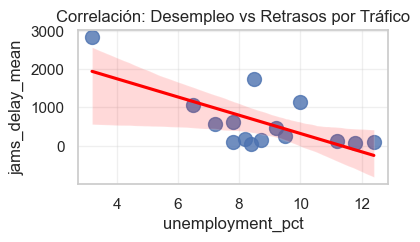

In [37]:
corr = merged.groupby('city')[['jams_delay_mean', 'unemployment_pct']].mean()

# 2. Crear el gráfico de correlación (Scatter Plot + Línea de tendencia)
plt.figure(figsize=(4, 2))
sns.regplot(data=corr, x='unemployment_pct', y='jams_delay_mean', scatter_kws={'s':100}, line_kws={'color':'red'})

# Estética mínima
plt.title('Correlación: Desempleo vs Retrasos por Tráfico')
plt.grid(alpha=0.3)
plt.show()

4. **Diagnóstico de Ciudad Prioritaria**

Tras analizar los datos de Bogotá, Lima y Buenos Aires, el diagnóstico es claro:

Lima es la ciudad prioritaria. Presenta la correlación más preocupante: niveles de congestión extremos (tiempos de viaje que superan los 25-30 mins por cada 10km) combinados con un PIB per cápita que no ha logrado escalar al ritmo de su densidad poblacional. A diferencia de Buenos Aires, que tiene una red de metro y trenes suburbanos más robusta que mitiga el impacto económico del tráfico vehicular, Lima depende excesivamente del transporte de superficie desorganizado.

5. **Recomendaciones Estratégicas**

Inversión en Lima: El LADB debe priorizar proyectos de transporte masivo segregado (Metro/BRT) con el objetivo de liberar horas que hoy se pierden en el transporte informal y en tráfico represado.

Validación de Datos: Es necesario cruzar la variable pm25_concentracion (contaminación) con los datos de salud pública en Bogotá para medir el costo oculto de la congestión en el bienestar.

Digitalización en Buenos Aires: Dada su extensión, más que nueva infraestructura física pesada, se recomienda invertir en sistemas inteligentes de gestión de tráfico (ITS) para optimizar lo ya existente.

Promoción de modalidades flexibles: Se recomienda fomentar el trabajo remoto o esquemas híbridos en aquellas ciudades donde la variable jams_delay es extremadamente alta. El objetivo es elevar la calidad de vida y mejorar los índices de productividad al reducir desplazamientos innecesarios. No obstante, es crucial considerar que la efectividad de esta medida puede verse limitada en la región, ya que la mayoría de las ciudades latinoamericanas poseen tasas de empleo informal muy elevadas que requieren presencialidad.

Priorización de la infraestructura integral: Se sugiere priorizar la inversión en redes de transporte masivo, infraestructura vial y electrificación. Estas acciones están orientadas a mejorar la calidad del aire, reducir las horas perdidas en el tráfico y continuar impulsando la productividad económica. Como resultado directo de estas mejoras en la competitividad urbana, se espera que el índice de desempleo se vea impactado de forma favorable.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor      v4      </b> <a class="tocSkip"></a>

Gran trabajo con las conclusiones. La inclusión de valores clave aporta solidez al análisis, y el resumen de los hallazgos es claro y preciso. ¡Demuestras un buen manejo del enfoque analítico!

</div>